## linear regression model dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

GEN_PATH = '../../01_data/2_cleaned/generation/hourly_solar_wind_generation_2020_2025.parquet'
LOAD_PATH = '../../01_data/2_cleaned/load/total_load_20201231_20260526.csv'
CAPACITY_PATH = '../../01_data/2_cleaned/generation/ERCOT nonRE capacity 2020-2025.csv'
PRICE_PATH = '../../01_data/2_cleaned/rtm_price/rtm_price_aggregated_2021_2025.csv'
NG_PATH = '../../01_data/3_analysis/ng_price/ng_prices_monthly.csv'
TEMP_PATH = '../../01_data/2_cleaned/weather/Texas_hourly_temp_2021_2025.csv'

OUT_DIR = Path('../../01_data/4_model')

In [2]:
df_gen = pd.read_parquet(GEN_PATH)
df_load = pd.read_csv(LOAD_PATH)
df_capacity = pd.read_csv(CAPACITY_PATH)
df_total_cap = df_capacity.filter(['year', 'total_mw'])
df_total_cap = df_total_cap.rename(columns={'total_mw': 'non_re_capacity'})
df_total_cap['non_re_capacity'] = df_total_cap['non_re_capacity'].astype(int)

df_price = pd.read_csv(PRICE_PATH)
df_price = df_price.filter(['date_time', 'avg_rtm_price'])
df_price = df_price.rename(columns={'date_time': 'datetime', 'avg_rtm_price' : 'rtm_price'})

df_ng = pd.read_csv(NG_PATH)
df_ng = df_ng[(df_ng['date']>= '2021-01-01') & (df_ng['date']<= '2025-12-01')]
df_ng['date'] = pd.to_datetime(df_ng['date'])
df_ng['month'] = df_ng['date'].dt.month
df_ng['year'] = df_ng['date'].dt.year

df_temp = pd.read_csv(TEMP_PATH)

In [24]:
import duckdb

# without uri dates

con = duckdb.connect()
df = con.execute("""
   WITH Merged AS (
      SELECT
         g.datetime
         ,MONTH(g.datetime) AS month
         ,rtm_price
         ,renewable_gen
         ,total_load
         ,non_re_capacity
         ,henry_hub AS ng_price
         ,tx_temp
      
      FROM df_gen g
         JOIN df_load l ON g.datetime = l.datetime
         LEFT JOIN df_total_cap c ON YEAR(g.datetime) = c.year
         JOIN df_price p ON g.datetime = p.datetime
         LEFT JOIN df_ng n ON YEAR(n.date) = YEAR(g.datetime)
                           AND MONTH(n.date) = MONTH(g.datetime)
         LEFT JOIN df_temp t ON t.datetime = g.datetime
      WHERE CAST(g.datetime AS DATE) <= '2021-02-13' OR CAST(g.datetime AS DATE) >= '2021-02-25'                 
      )
   
   SELECT
         datetime
         ,YEAR(datetime) AS year
         ,HOUR(datetime) AS time_of_day
         ,CASE WHEN month IN (12, 1, 2)  THEN 'winter'
               WHEN month IN (3, 4, 5)   THEN 'spring'
               WHEN month IN (6, 7, 8)   THEN 'summer'
               WHEN month IN (9, 10, 11) THEN 'fall'
          END AS season
         ,rtm_price
         ,total_load
         ,(total_load - renewable_gen)/non_re_capacity AS spare_capacity
         ,ng_price
         ,ABS(tx_temp - 65) AS degree_days
   FROM Merged
   ORDER BY datetime;
""").fetchdf()

df

,datetime,year,time_of_day,season,rtm_price,total_load,spare_capacity,ng_price,degree_days
0,2021-01-01 01:00:00,2021,1,winter,18.714000,43713.80,0.447794,2.712632,26.0
1,2021-01-01 02:00:00,2021,2,winter,18.107333,43314.37,0.437193,2.712632,27.0
2,2021-01-01 03:00:00,2021,3,winter,17.570000,43048.35,0.434211,2.712632,29.0
3,2021-01-01 04:00:00,2021,4,winter,17.670667,43073.65,0.449278,2.712632,29.0
4,2021-01-01 05:00:00,2021,5,winter,17.792000,43448.89,0.470151,2.712632,30.0
...,...,...,...,...,...,...,...,...,...
43025,2025-12-27 20:00:00,2025,20,winter,17.682000,54126.08,0.393060,4.263810,15.0
43026,2025-12-27 21:00:00,2025,21,winter,15.002667,52877.78,0.374186,4.263810,16.0
43027,2025-12-27 22:00:00,2025,22,winter,13.227333,51837.59,0.369187,4.263810,14.0
43028,2025-12-27 23:00:00,2025,23,winter,14.328667,50370.39,0.349536,4.263810,12.0


### data inspection and export

In [25]:
summary = pd.DataFrame({
    "col_name": df.columns,
    "dtype": df.dtypes,
    "n_missing": [df[col].isna().sum() for col in df.columns],
    "missing_rate": [round(df[col].isna().mean()*100, 2) for col in df.columns],
    "is_unique": df.columns.duplicated(),
    "n_unique": [df[col].nunique() for col in df.columns],
    "sample_values": [list(df[col].unique()[0:3]) for col in df.columns]
})
summary

,col_name,dtype,n_missing,missing_rate,is_unique,n_unique,sample_values
datetime,datetime,datetime64[us],0,0.0,False,43021,"[2021-01-01 01:00:00, 2021-01-01 02:00:00, 202..."
year,year,int64,0,0.0,False,5,"[2021, 2022, 2023]"
time_of_day,time_of_day,int64,0,0.0,False,24,"[1, 2, 3]"
season,season,str,0,0.0,False,4,"[winter, spring, summer]"
rtm_price,rtm_price,float64,0,0.0,False,34731,"[18.714, 18.107333333333333, 17.57]"
total_load,total_load,float64,0,0.0,False,42761,"[43713.8, 43314.37, 43048.35]"
spare_capacity,spare_capacity,float64,0,0.0,False,43016,"[0.44779394487121554, 0.4371928001205001, 0.43..."
ng_price,ng_price,float64,0,0.0,False,60,"[2.7126315789473683, 5.353684210526316, 2.6182..."
degree_days,degree_days,float64,0,0.0,False,53,"[26.0, 27.0, 29.0]"


In [6]:
df.to_csv(OUT_DIR / 'ercot_regression_model_dataset.csv', index=False)

### correlation plots

/Users/zyliazhang/Git/ERCOT-Research/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


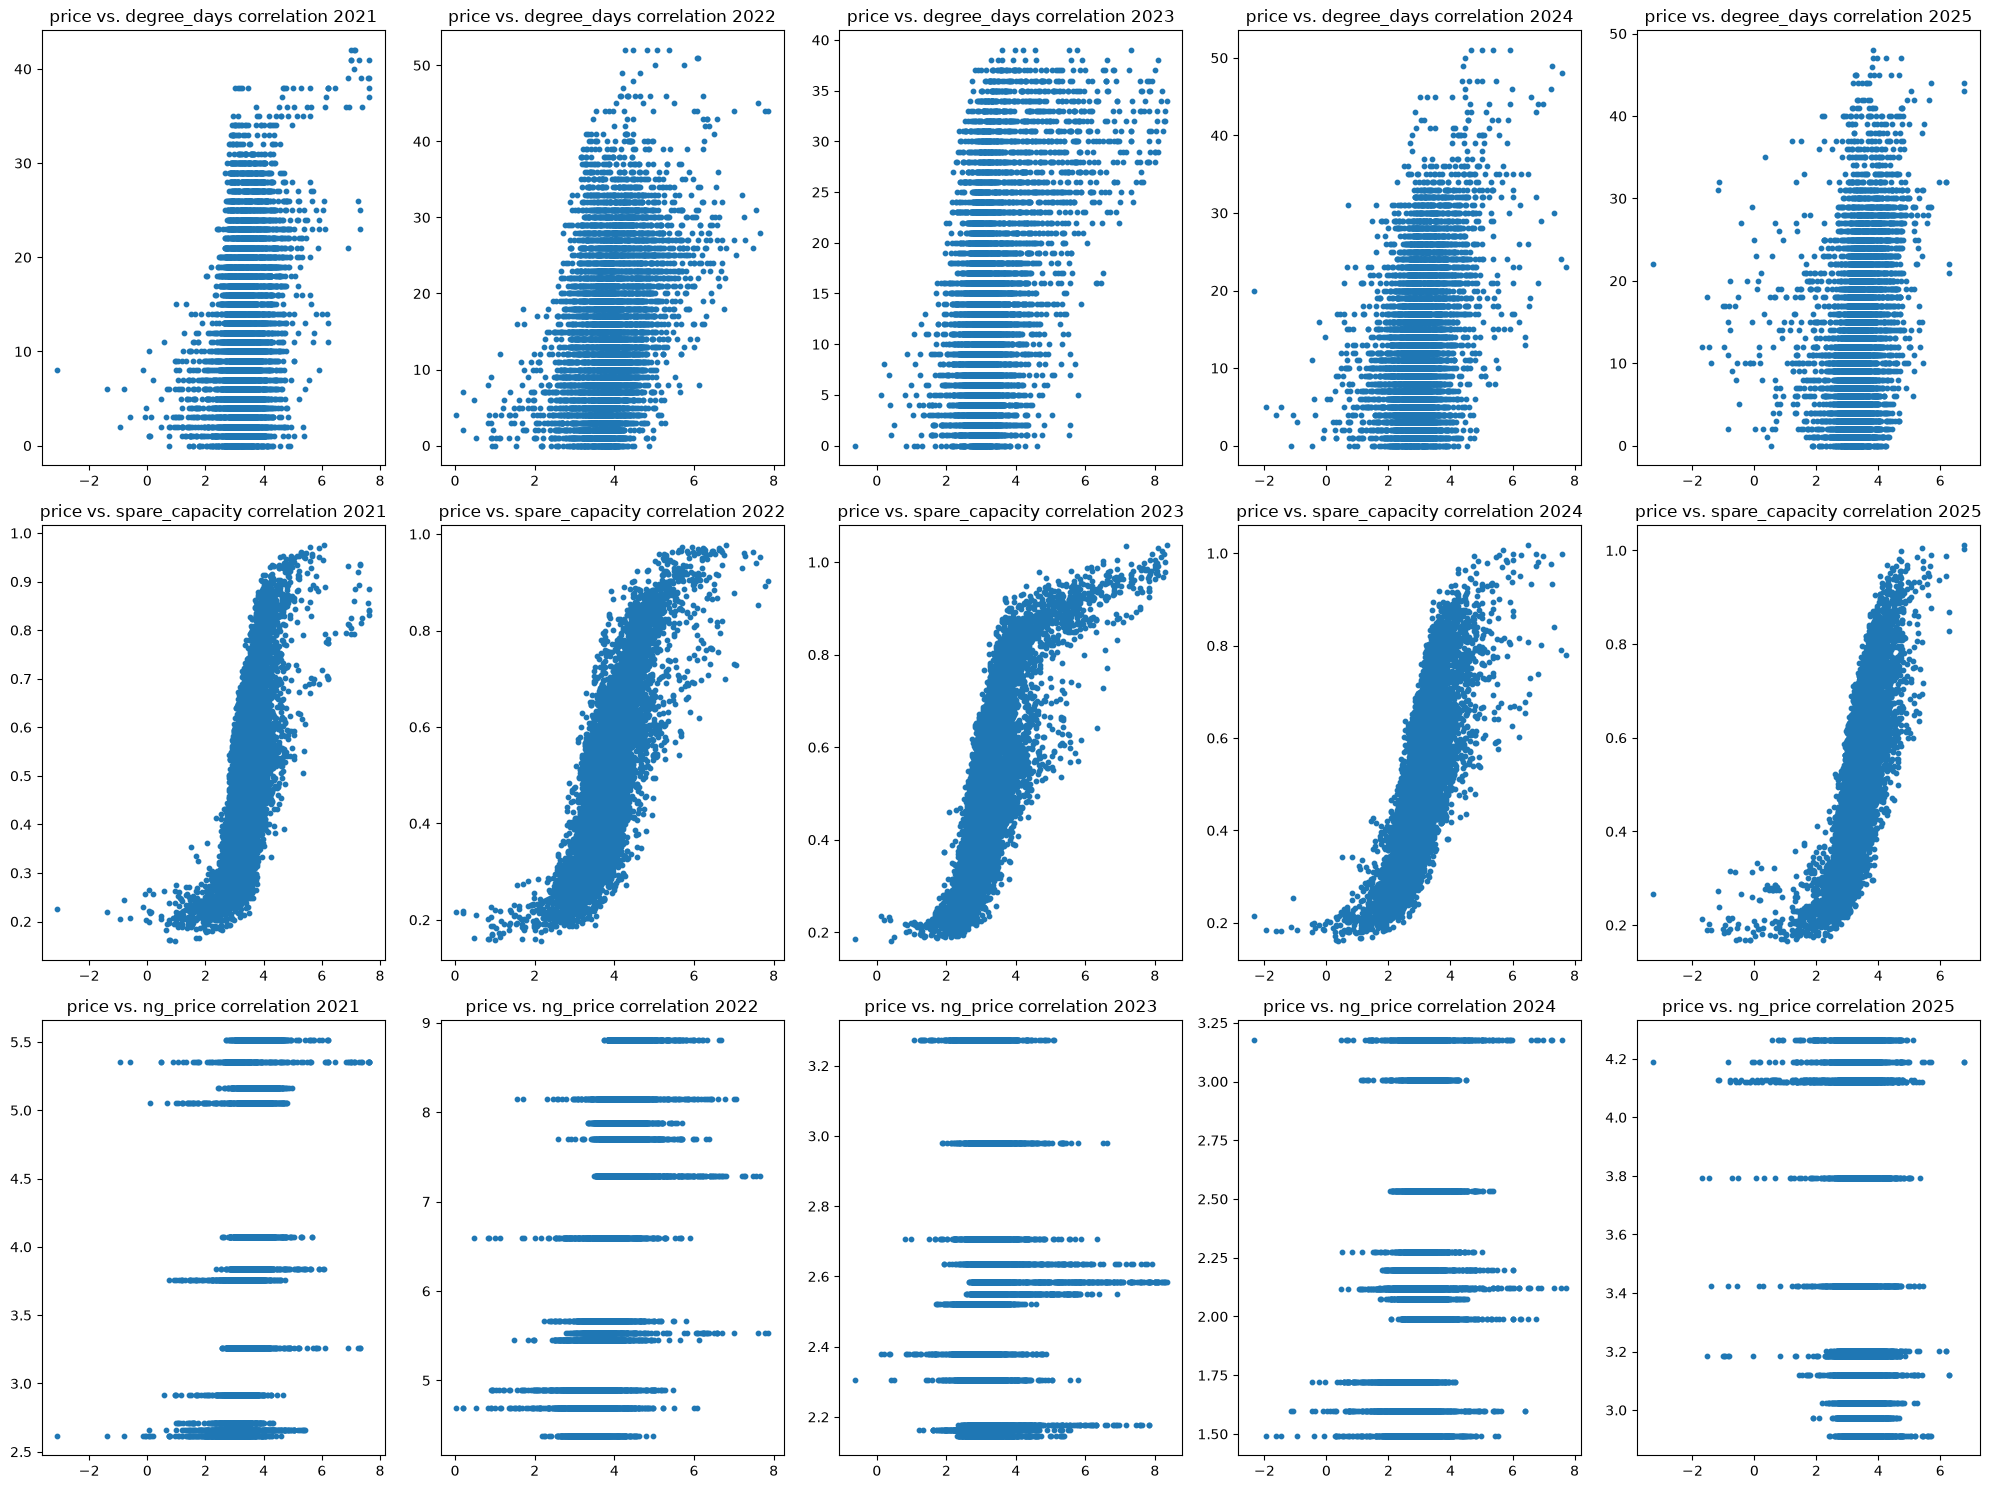

In [26]:
fig, axes = plt.subplots(3, 5, figsize=(20, 15))

years = [2021, 2022, 2023, 2024, 2025]
columns = ['degree_days', 'spare_capacity', 'ng_price']

for j, year in enumerate(years):
    df_year = df[df['year'] == year]
    for i, col in enumerate(columns):
        axes[i,j].scatter(np.log(df_year['rtm_price']), df_year[col], s=10)
        axes[i,j].set_title(f'price vs. {col} correlation {year}')

plt.tight_layout()
plt.show()

In [27]:
print('overall correlation:')
# without uri
df_cor = df.filter(['rtm_price', 'degree_days', 'spare_capacity', 'ng_price'])
corr_matrix = df_cor.corr(method='pearson')
print(corr_matrix)

overall correlation:
                rtm_price  degree_days  spare_capacity  ng_price
rtm_price        1.000000     0.214668        0.324405  0.112071
degree_days      0.214668     1.000000        0.519837  0.085448
spare_capacity   0.324405     0.519837        1.000000  0.080414
ng_price         0.112071     0.085448        0.080414  1.000000


In [28]:
for year in [2021, 2022, 2023, 2024, 2025]:
    df_year = df[df['year'] == year]
    df_cor = df_year.filter(['rtm_price', 'spare_capacity', 'ng_price', 'degree_days'])
    corr_matrix = df_cor.corr(method='pearson')
    print(f'\n===== {year} ======')
    print(corr_matrix)


===== 2021 ======
                rtm_price  spare_capacity  ng_price  degree_days
rtm_price        1.000000        0.304595  0.154331     0.213479
spare_capacity   0.304595        1.000000  0.175584     0.483976
ng_price         0.154331        0.175584  1.000000     0.047050
degree_days      0.213479        0.483976  0.047050     1.000000

===== 2022 ======
                rtm_price  spare_capacity  ng_price  degree_days
rtm_price        1.000000        0.489052  0.241044     0.255662
spare_capacity   0.489052        1.000000  0.427852     0.510008
ng_price         0.241044        0.427852  1.000000     0.076435
degree_days      0.255662        0.510008  0.076435     1.000000

===== 2023 ======
                rtm_price  spare_capacity  ng_price  degree_days
rtm_price        1.000000        0.359522  0.003269     0.250665
spare_capacity   0.359522        1.000000 -0.044460     0.570386
ng_price         0.003269       -0.044460  1.000000     0.055621
degree_days      0.250665        